In [1]:
import os
os.chdir('../../')
from Libreria import Preferences
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
#from tabula.io import read_pdf


# Lecura de datos

In [2]:
# CUSTOM CONFIG
DATASET = "chile"
MINIMUM_NUMBER_VOTES = 0

In [3]:
# ETL preferences
"""
Preferences corresponde a una clase que contiene los siguientes atributos
1. BOT_LIST                Resultados de bot_prediction
2. DATASET                 Nombre de la base de datos quiere se analizar. Puede ser chile, colombia, georgia y lebanon
3. FILTER                  Si es True, el dataframe de salida solo tendrá la información de los últimos votos por cada usuario.Por defecto es True.
4. LABELS                  Informacion de las propuestas
5. THRESHOLD_MIN_USER      Umbral de votos minimos por usuario. Por defecto es 10.
6. USERS                   Usuarios filtrados que cumplen con ciertos criterios
7. data                    Informacion filtrada de las votaciones realizadas
8. data_filtered           Informacion filtrada de las votaciones realizadas
9. data_processed          Información procesada. Utilizando la funcion transform_step se incorporan las columnas option_x_selected, option_x_sorted, card_id, option_source, option target y latest. Por defecto es data.
10. predicted_prob         Umbral para clasificar la predicción. El valor por defecto es 0.5
11. verbose                Si es True, se imprime en pantalla información de los filtros utilizados

También contiene una variable llamada DIFFERENTIAL_PRIVACY que por defecto es False. Si es True, asigna aleatoriamente una opción
en data['selected'].
"""

preferences = Preferences(DATASET, MINIMUM_NUMBER_VOTES)


# Procesamiento datos de votaciones

In [4]:
# Se analizará todas las votaciones de todos los usuarios
preferences.FILTER = False

# Process data
"""
Si el dataset es Chile, se puede filtrar por ciclo de votación. Las opciones se ciclo son las siguientes:
            "cycle_1": ["2019-10-24 11:35:05", "2019-10-31 01:35:54"],
            "cycle_2": ["2019-10-31 01:35:54", "2019-11-07 00:55:15"],
            "cycle_3": ["2019-11-07 00:55:15", "2019-11-14 13:10:08"],
            "cycle_4": ["2019-11-14 13:10:08", "2019-11-28 15:21:02"],
            "cycle_5": ["2019-11-28 15:21:02", "2099-12-31 23:59:59"]
            "all": Considera todos los ciclos anteriores
"""
# Se procesa los datos para el primer ciclo de votacion de votación.
preferences.transform_step()

completo =  preferences.data_processed.copy()
# Se guarda la información procesada de los datos
df = preferences.data_filtered.copy()

In [7]:
df.sort_values('datetime')

,id,uuid,option_a,option_b,selected,datetime,score_x,ip_hash,score_async,drawn,...,score_y,unique_uuid,n_ips,score_pred,delta,prediction,predicted_prob,rate_bots_same_ip,mean_predicted_prob,mean_prediction
0,5,8bd42737-b140-4db8-af4c-59839922129a,33,20,33,2019-10-24 11:40:24,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,0.90000,11,1,0,1621,0,0.000000,0.0,0.000000,0
1,6,8bd42737-b140-4db8-af4c-59839922129a,85,7,85,2019-10-24 11:41:33,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,0.90000,11,1,0,1621,0,0.000000,0.0,0.000000,0
2,7,8bd42737-b140-4db8-af4c-59839922129a,41,13,13,2019-10-24 11:41:36,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,0.90000,11,1,0,1621,0,0.000000,0.0,0.000000,0
3,8,8bd42737-b140-4db8-af4c-59839922129a,81,46,46,2019-10-24 11:41:41,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,0.90000,11,1,0,1621,0,0.000000,0.0,0.000000,0
4,10,8bd42737-b140-4db8-af4c-59839922129a,35,41,35,2019-10-24 11:44:16,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,0.90000,11,1,0,1621,0,0.000000,0.0,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3492543,3674848,f9ffb450-6f11-48b6-acc7-c13028a58a2e,79,66,66,2019-10-31 01:35:48,0.3,d998f058cb7c4a13faa6e825ee0f8b2fc3bc16febebbc4...,0.4,False,...,0.46513,1,1,1,13131,1,1.253316,1.0,1.253316,1
3598497,3674849,61ea8fa0-762d-4369-8ae5-d844c19e348e,5,43,43,2019-10-31 01:35:49,0.9,d70fb923ecd5130a3e57d62a3ef74fbd216c5d0ed3d64d...,0.4,False,...,0.90000,2,1,1,9349,1,1.253316,0.5,0.626658,1
3625357,3674850,3ddc9eae-ba7b-4dab-8e43-5c188daf9692,17,74,17,2019-10-31 01:35:50,0.9,a5221426b7542198500aa6b5e2d4c9ebf2d18d3184ca0b...,0.9,False,...,0.90000,1,1,1,2137,0,0.000000,0.0,0.000000,0
3624650,3674851,2e8f5550-d794-411c-b36e-d277e88f5d30,79,16,79,2019-10-31 01:35:51,0.9,96e06bd0e7356e99f1360b280c3c24c3aca7ee59dc0070...,0.9,False,...,0.90000,2,1,1,1859,0,0.000000,0.0,0.000000,0


In [5]:
"""
La data procesada contiene la siguiente información:

id                     Identficador usuario-voto
uuid                   Identificador usuario
option_a               Propuesta 1 en la votación
option_b               Propuesta 2 en la votación
selected               Propuesta escogida. Puede ser a o b.
datetime               Fecha de cuando se realiza la votación
score_x                ???Score de la base de datos. Aún no sé que significa
ip_hash                Direccion Ip
score_async            ???
drawn                  True si la propuesta seleccionada es 0
option_a_selected      1 si la propuesta seleccionada es a. 0 caso contrario
option_b_selected      1 si la propuesta seleccionada es b. 0 caso contrario
option_a_sorted        Propuesta que tiene el identificador más pequeño
option_b_sorted        Propuesta que tiene el identificador mayor
card_id                Id del emparejamiento de propuestas. Se define de la forma 1 + <proposal_a> + <proposal_b>. Cada <proposal_a> tiene 3 digitos
option_source          Chequea si a/b fue seleccionada. Option source es aquella que no fue seleccionada.   
option_target          Chequea si a/b fue seleccionada. Option target es aquella que fue seleccionada.
latest                 Filtra el conjunto de datos por último voto válido, basado en card_id. Se asigna un '1' al último voto de cada usuario.
mean                   Media calculada  a partir de la cantidad de pares de propuestas que tuvo que votar el usuario
std                    Std calculada  a partir de la cantidad de pares de propuestas que tuvo que votar el usuario
registered             Información de registro de cada usuario en la plataforma. Es un '1' si es que está registrado.
is_bot                 Información de si corresponde a un bot o no, según las detecciones realizadas en las capas anteriores.
transitivity           Transitividad por cada usuario. Esto es la probabilidad general de que la red tenga nodos adyacentes interconectados, lo que revela la existencia de comunidades estrechamente conectadas entre las propuestas. Se utilizan digrafos. 
count                  Cantidad de votaciones por usuario
rate                   Tasa de votaciones en un intervalo de tiempo (delta)
score_y                ??? Actualización del valor score en base a la cantidad de votaciones y el valor del rate. Los valores pueden ser 0.9 o 0.1
unique_uuid            ??? Creo que corresponden al número de usuarios que votaron por la misma IP, pero está mal realizado.
n_ips                  Cantidad de IP utilizadas por el usuario
score_pred             ??? Valor de score que aparece en la base de datos de usuarios
delta                  Tiempo transcurrido entre la primera y última votación
prediction             Clasificación realizada por el modelo de si es o no bot
predicted_prob         Probabilidad predicha por el modelo para ser bot.
rate_bots_same_ip      Tasa de bots con respecto a la cantidad de usuarios que tienen la misma IP
mean_predicted_prob    Promedio de probabilidades de predicción por IP
mean_prediction'       Clasificación del promedio de probabilidades de predicción por IP
"""
df.head()

,id,uuid,option_a,option_b,selected,datetime,score_x,ip_hash,score_async,drawn,...,score_y,unique_uuid,n_ips,score_pred,delta,prediction,predicted_prob,rate_bots_same_ip,mean_predicted_prob,mean_prediction
0,5,8bd42737-b140-4db8-af4c-59839922129a,33,20,33,2019-10-24 11:40:24,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,0.9,11,1,0,1621,0,0.0,0.0,0.0,0
1,6,8bd42737-b140-4db8-af4c-59839922129a,85,7,85,2019-10-24 11:41:33,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,0.9,11,1,0,1621,0,0.0,0.0,0.0,0
2,7,8bd42737-b140-4db8-af4c-59839922129a,41,13,13,2019-10-24 11:41:36,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,0.9,11,1,0,1621,0,0.0,0.0,0.0,0
3,8,8bd42737-b140-4db8-af4c-59839922129a,81,46,46,2019-10-24 11:41:41,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,0.9,11,1,0,1621,0,0.0,0.0,0.0,0
4,10,8bd42737-b140-4db8-af4c-59839922129a,35,41,35,2019-10-24 11:44:16,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,0.9,11,1,0,1621,0,0.0,0.0,0.0,0


# Procesamiento datos de usuarios

In [6]:
# Se extrae la información de los usuarios
USERS = preferences.USERS.copy()

# Se crea una columna count y asigna a todas las filas un valor de 1.
USERS["count"] = 1

def find_gen(x):
    """
    Función que clasifica cada usuario en una generación social. Esto se realiza en base a la edad del usuario
    
    Parametros:
    x (int): Edad del usuario

    Returns:
    Nombre generacional
        
    """
    gens = [
        {"name": "Generation Z", "start": 1994, "end": 2010},
        {"name": "Millennial", "start": 1981, "end": 1993},
        {"name": "Generation X", "start": 1969, "end": 1980},
        {"name": "Baby Boomer", "start": 1949, "end": 1969},
        {"name": "Silent Generation", "start": 1930,"end": 1948}
    ]
    age = 2019 - x
    for i in gens:
        if i["start"] <= age and age <= i["end"]:
            return i["name"]
    return ""

def convert_region(x):
    """
    Función que asigna a cada usuario una región personalizada.  Se realiza en base a la región en la que viven.
    Las opciones son 'capital city', 'outside country' y 'region'.
    
    Parametros:
    x (str): Región a la que pertenece el usuario

    Returns:
    Nombre de la región personalizada
        
    """
    if x in ["Bogotá D.C.", "Santiago Metropolitan", "Metropolitana de Santiago"]:
        return "Capital City"
    elif x in ["Fuera de Colombia", "Fuera de Chile", "Outside of Chile"]:
        return "Outside Country"
    else:
        return "Region"

def find_pol(x):
    """
    Función que asigna a cada usuario un espectro político.  Se realiza en base al partido político.
    Las opciones son 'Center', 'Right' y 'Left'.
    
    Parametros:
    x (int): Número del partido político de cada usuario

    Returns:
    Espectro polítco de cada usuario
        
    """
    if x == 5:
        return "Center"
    elif x > 5:
        return "Right"
    else:
        return "Left"

USERS["politica_custom"] = USERS["politica"].apply(find_pol)
USERS["region_custom"] = USERS["region"].apply(convert_region)
USERS["age_gen"] = USERS["age"].apply(find_gen)
# Definir los rangos de edades
bins = [18, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, float('inf')]
labels = ['18-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80+']

# Aplicar la transformación
USERS['age_range_2'] = pd.cut(USERS['age'], bins=bins, labels=labels)


In [7]:
"""
El dataset de usuario contiene la siguiente información:

id                   Identficador información usuario. Es importante mencionar que esta id es distinta al 'id' de la información de las votaciones.
uuid                 Identificador usuario
sex                  Genero del usuario
age                  Edad del usuario
region               Región en la que vive el usuario
politica             Partido político al que pertenece el usuario
datetime             Fecha de registro del usuario
score                ???
ip_hash              Dirección IP
age_range            Rango de edad a la que pertenece el usuario
count                Valor 1
politica_custom      Espectro político del usuario
region_custom        Región personalizada del usuario
age_gen              Generación social del usuario
"""
USERS.head()

,id,uuid,sex,age,region,politica,datetime,score,ip_hash,age_range,count,politica_custom,region_custom,age_gen,age_range_2
8574,8505,000057c7-295c-4a61-8f62-76aff62bf079,Masculino,27,Metropolitana de Santiago,8,2019-10-24 23:11:23,NaN,NaN,"(25.0, 30.0]",1,Right,Capital City,Millennial,25-29
37953,38074,000059b8-10b9-4f74-9c01-80bd2c48f509,Masculino,37,Metropolitana de Santiago,5,2019-10-29 12:10:19,NaN,NaN,"(35.0, 40.0]",1,Center,Capital City,Millennial,35-39
79827,79872,0000d93e-3301-4ec7-ba33-e9ecc8bdd77d,Masculino,18,Valparaíso,4,2019-11-03 17:12:49,NaN,dc8576e8fe19362c62aaae4ba775530e8070a37b438a9c...,"(17.999, 25.0]",1,Left,Region,Generation Z,NaN
57574,57539,0001c354-8814-4280-ba62-1e9a7af4edad,Masculino,29,Metropolitana de Santiago,5,2019-11-01 18:12:25,NaN,0ccdd31ba4e3273ada3f2e1bc6e49f8ca833d00aaf3bc2...,"(25.0, 30.0]",1,Center,Capital City,Millennial,25-29
18142,18246,00032199-2183-48c0-8f0d-ac37dc8ece60,Masculino,33,Valparaíso,6,2019-10-25 17:04:27,NaN,NaN,"(30.0, 35.0]",1,Right,Region,Millennial,30-34


# Union datos de votaciones y usuarios

In [8]:
# Se cruza la información de votaciones con la información de los usuarios
df_preferences_users = df.merge(USERS, on="uuid")
df_preferences_users.head()

,id_x,uuid,option_a,option_b,selected,datetime_x,score_x,ip_hash_x,score_async,drawn,...,politica,datetime_y,score,ip_hash_y,age_range,count_y,politica_custom,region_custom,age_gen,age_range_2
0,5,8bd42737-b140-4db8-af4c-59839922129a,33,20,33,2019-10-24 11:40:24,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
1,6,8bd42737-b140-4db8-af4c-59839922129a,85,7,85,2019-10-24 11:41:33,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
2,7,8bd42737-b140-4db8-af4c-59839922129a,41,13,13,2019-10-24 11:41:36,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
3,8,8bd42737-b140-4db8-af4c-59839922129a,81,46,46,2019-10-24 11:41:41,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
4,10,8bd42737-b140-4db8-af4c-59839922129a,35,41,35,2019-10-24 11:44:16,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29


In [9]:
df_preferences_users

,id_x,uuid,option_a,option_b,selected,datetime_x,score_x,ip_hash_x,score_async,drawn,...,politica,datetime_y,score,ip_hash_y,age_range,count_y,politica_custom,region_custom,age_gen,age_range_2
0,5,8bd42737-b140-4db8-af4c-59839922129a,33,20,33,2019-10-24 11:40:24,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
1,6,8bd42737-b140-4db8-af4c-59839922129a,85,7,85,2019-10-24 11:41:33,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
2,7,8bd42737-b140-4db8-af4c-59839922129a,41,13,13,2019-10-24 11:41:36,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
3,8,8bd42737-b140-4db8-af4c-59839922129a,81,46,46,2019-10-24 11:41:41,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
4,10,8bd42737-b140-4db8-af4c-59839922129a,35,41,35,2019-10-24 11:44:16,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3065872,3673831,1a38e668-bad8-41e5-9e24-050480272131,72,87,87,2019-10-31 01:20:28,0.9,51becea9292f64280ddcc3bc2b517763182aaa4e49a012...,0.9,False,...,3,2019-10-31 01:16:53,NaN,NaN,"(55.0, 60.0]",1,Left,Region,Baby Boomer,55-59
3065873,3673840,1a38e668-bad8-41e5-9e24-050480272131,32,29,32,2019-10-31 01:20:33,0.9,51becea9292f64280ddcc3bc2b517763182aaa4e49a012...,0.9,False,...,3,2019-10-31 01:16:53,NaN,NaN,"(55.0, 60.0]",1,Left,Region,Baby Boomer,55-59
3065874,3673848,1a38e668-bad8-41e5-9e24-050480272131,71,26,26,2019-10-31 01:20:38,0.9,51becea9292f64280ddcc3bc2b517763182aaa4e49a012...,0.9,False,...,3,2019-10-31 01:16:53,NaN,NaN,"(55.0, 60.0]",1,Left,Region,Baby Boomer,55-59
3065875,3673856,1a38e668-bad8-41e5-9e24-050480272131,75,2,75,2019-10-31 01:20:45,0.9,51becea9292f64280ddcc3bc2b517763182aaa4e49a012...,0.9,False,...,3,2019-10-31 01:16:53,NaN,NaN,"(55.0, 60.0]",1,Left,Region,Baby Boomer,55-59


# Demographic Distribution
## Age and Sex distribution

In [12]:
y_axis = "age_range_2"

# Cuenta las votaciones según rango de edad y sexo
pop = df_preferences_users.groupby([y_axis, "sex"]).agg({"id_x": "nunique"}).reset_index()

# Selecciona la información del sexo masculino
male = pop[pop["sex"].isin(["Male", "Masculino"])].copy()
# Selecciona la información del sexo femenino
female = pop[pop["sex"].isin(["Female", "Femenino"])].copy()

# Convierte el número de votos en un número negativo para poder graficarlo al lado izquierdo con respecto al cero.
female["id_x"] = female["id_x"] * -1

# Número levemente mayor al máximo de votos por usuario. Se define este valor para ocuparlo como xlim en las sgtes figuras.
m = pop["id_x"].abs().max() * 1.1

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7464\4167834628.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pop = df_preferences_users.groupby([y_axis, "sex"]).agg({"id_x": "nunique"}).reset_index()


## Political and Region Distribution

In [13]:
x = "region_custom"
y = "politica_custom"
z = "age_custom"

# Cuenta las votaciones se espectro politico y region
c = df_preferences_users.groupby([x, y]).agg({"uuid": "nunique", "id_y": "count"})
c = c.reset_index()

# Tasa de número de votos por usuario
c["rate"] = c["id_y"] / c["uuid"]

c = c.rename(columns={"uuid": "n_users", "id_y": "n_votes"})


In [14]:
c

,region_custom,politica_custom,n_users,n_votes,rate
0,Capital City,Center,9509,760669,79.994637
1,Capital City,Left,8095,622257,76.869302
2,Capital City,Right,6884,568777,82.623039
3,Outside Country,Center,234,15417,65.884615
4,Outside Country,Left,410,25760,62.829268
5,Outside Country,Right,143,9213,64.426573
6,Region,Center,6080,485407,79.836678
7,Region,Left,4073,321631,78.966609
8,Region,Right,2618,256746,98.069519


## Plot Distributions

C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_7464\3780460985.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(xlabels)


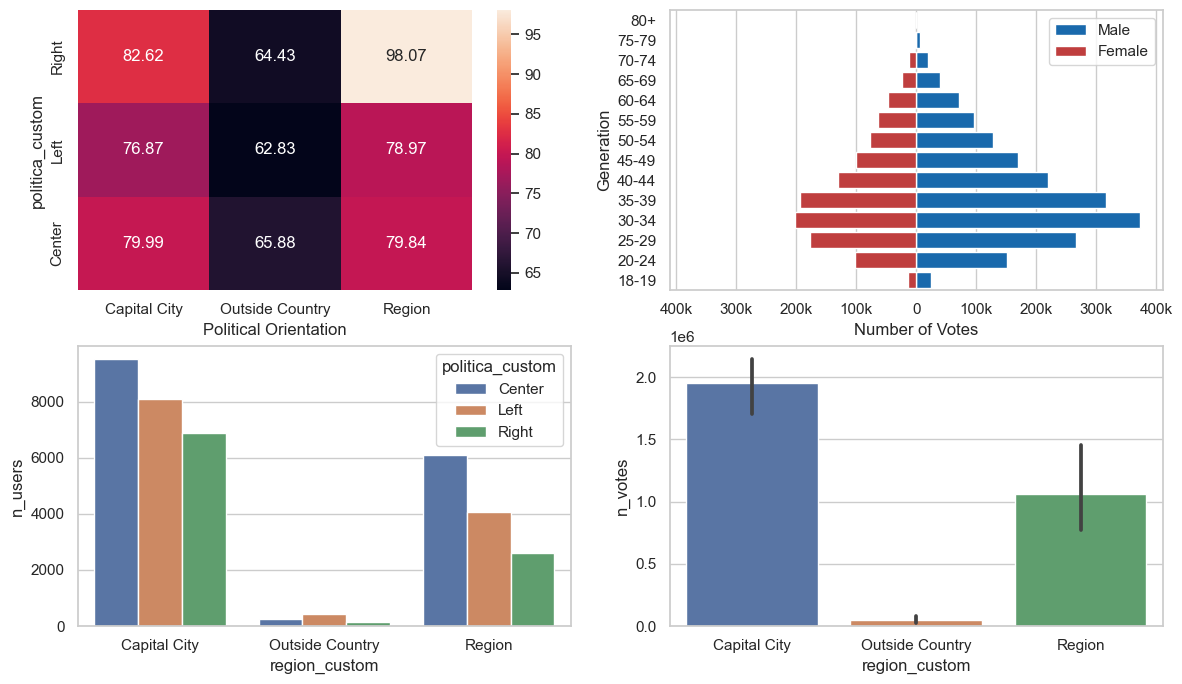

In [15]:
data = c.pivot(index=y, columns=x, values="rate")
order=["Generation Z", "Millennial", "Generation X", "Baby Boomer", "Silent Generation"]
sns.set(rc={"figure.figsize": (14, 8)}, style="whitegrid")

f, axes = plt.subplots(2, 2)
#Figura arriba a la derecha
ax = sns.barplot(y=y_axis, x="id_x", data=male, color="#006BC5", ax=axes[0, 1],label='Male') 
ax = sns.barplot(y=y_axis, x="id_x", data=female, color="#D42929", ax=axes[0, 1],label='Female')
ax.invert_yaxis()
ax.set_xlabel("Number of Votes")
ax.set_ylabel("Generation")
ax.set_xlim(-m, m)
ax.legend()
def set_ticks(x):
    if x == 0:
        return 0
    return "{:,.0f}".format(abs(x) / 1000) + "k"

xlabels = [set_ticks(x) for x in ax.get_xticks()]
ax.set_xticklabels(xlabels)

# Figura arriba a la izquierda
ax = sns.heatmap(data, annot=True, fmt=".2f", ax=axes[0, 0])
ax.invert_yaxis()


ax.set_xlabel("Political Orientation")

# Figura abajo a la derecha
ax = sns.barplot(y="n_votes", x="region_custom", data=c, estimator=sum, ax=axes[1, 1])

# Figura abajo a la izquierda
ax = sns.barplot(x="region_custom", y="n_users", hue="politica_custom", data=c, ax=axes[1, 0])


**A continuación se grafica los porcentajes del  sexo y el rango etario de los votantes en cada votación**

C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


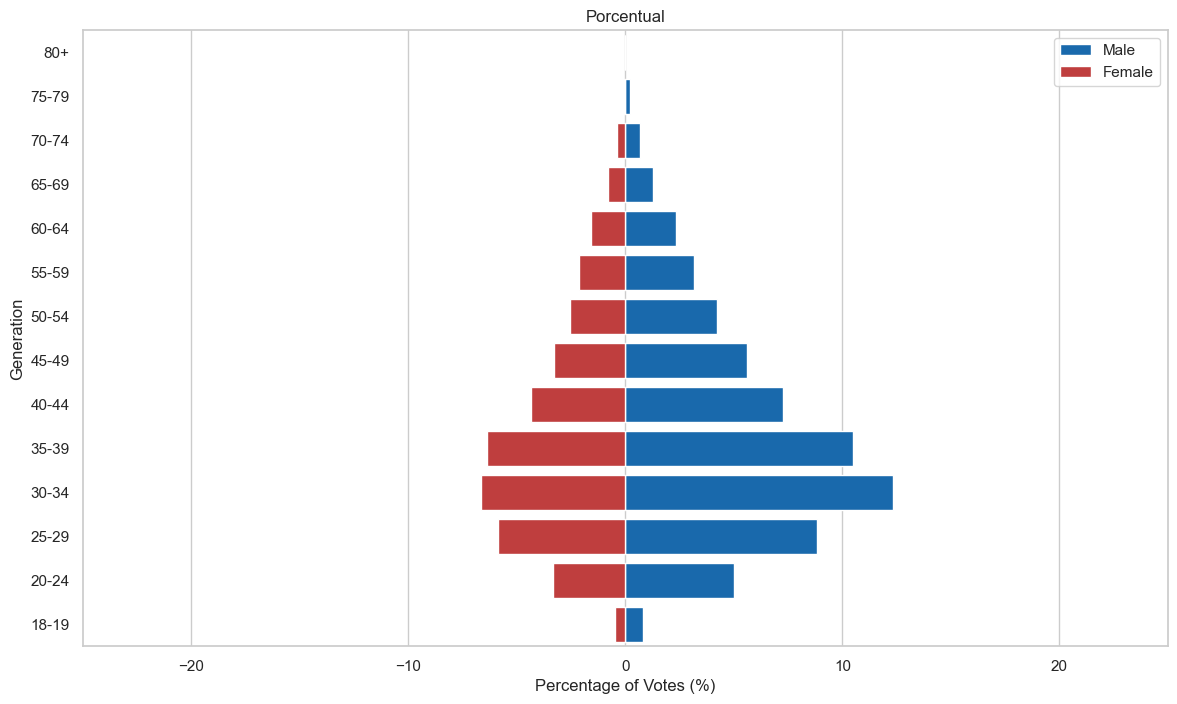

In [16]:

# Calcula los porcentajes para los datos masculinos y femeninos
total_votes = male["id_x"].abs().sum() +female["id_x"].abs().sum()

male_percent = male.copy()
female_percent = female.copy()
male_percent["id_x"] = (male["id_x"].abs() / total_votes) * 100
female_percent["id_x"] = (female["id_x"].abs() / total_votes) * 100*-1

m=25
# Crea una figura y ejes
f, axes = plt.subplots(1, 1)

# Dibuja el gráfico de barras apiladas porcentuales
ax = sns.barplot(y=y_axis, x="id_x", data=male_percent, color="#006BC5", label="Male")
ax = sns.barplot(y=y_axis, x="id_x", data=female_percent, color="#D42929", label="Female")

# Invierte el eje Y
ax.invert_yaxis()

# Establece etiquetas de ejes y límites
ax.set_xlabel("Percentage of Votes (%)")
ax.set_ylabel("Generation")
ax.set_xlim(-m, m)
ax.set_title('Porcentual')
ax.legend()
# Muestra el gráfico
plt.show()


**A continuación se grafica los porcentajes del sexo y el rango etario´de cada votante único**

C:\Users\Usuario\AppData\Local\Temp\ipykernel_7464\2940451861.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pop = df_preferences_users_sex.groupby([y_axis, "sex"]).agg({"uuid": "count"}).reset_index()
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\Usuario\.conda\envs\NNN\lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or 

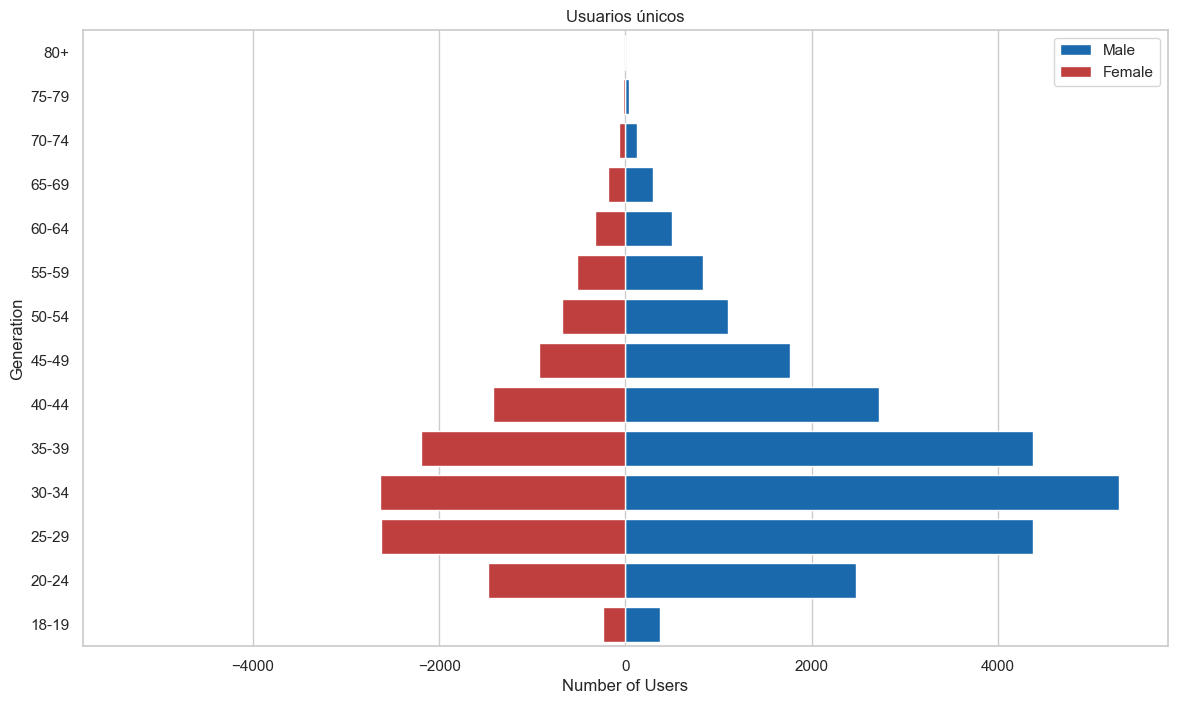

In [18]:
y_axis = "age_range_2"

df_preferences_users_sex= df_preferences_users[['uuid','sex','age_range_2']].drop_duplicates()
# Cuenta las votaciones según rango de edad y sexo
pop = df_preferences_users_sex.groupby([y_axis, "sex"]).agg({"uuid": "count"}).reset_index()

# Selecciona la información del sexo masculino
male = pop[pop["sex"].isin(["Male", "Masculino"])].copy()
# Selecciona la información del sexo femenino
female = pop[pop["sex"].isin(["Female", "Femenino"])].copy()

# Convierte el número de votos en un número negativo para poder graficarlo al lado izquierdo con respecto al cero.
female["uuid"] = female["uuid"] * -1

# Número levemente mayor al máximo de votos por usuario. Se define este valor para ocuparlo como xlim en las sgtes figuras.
m = pop['uuid'].abs().max() * 1.1

f, axes = plt.subplots(1, 1)
#Figura arriba a la derecha
ax = sns.barplot(y=y_axis, x="uuid", data=male, color="#006BC5",label='Male') 
ax = sns.barplot(y=y_axis, x="uuid", data=female, color="#D42929",label='Female')
ax.invert_yaxis()
ax.set_xlabel("Number of Users")
ax.set_ylabel("Generation")
ax.set_title('Usuarios únicos')
ax.set_xlim(-m, m)
ax.legend()
plt.show()


In [22]:
# Sort by 'datetime' to prioritize earlier entries
userMetadata = df_preferences_users.sort_values(by='datetime_y')
userMetadata

,id_x,uuid,option_a,option_b,selected,datetime_x,score_x,ip_hash_x,score_async,drawn,...,politica,datetime_y,score,ip_hash_y,age_range,count_y,politica_custom,region_custom,age_gen,age_range_2
0,5,8bd42737-b140-4db8-af4c-59839922129a,33,20,33,2019-10-24 11:40:24,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
34,666,8bd42737-b140-4db8-af4c-59839922129a,66,74,66,2019-10-24 11:57:35,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
35,1089,8bd42737-b140-4db8-af4c-59839922129a,59,69,59,2019-10-24 11:59:01,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
36,1178,8bd42737-b140-4db8-af4c-59839922129a,22,43,43,2019-10-24 11:59:13,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
37,1253,8bd42737-b140-4db8-af4c-59839922129a,54,11,11,2019-10-24 11:59:24,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2726982,3423338,7fabfb44-df09-4187-8d2d-b32cd124e9f0,31,16,16,2019-10-30 17:56:04,0.9,0e0ca4aabec9a26ac04779bbc8a7300a9823eae0103f1d...,0.4,False,...,1,2019-11-06 15:40:44,NaN,2b848dadba1449ba6ffccaddcf080d4fbf35510bcea73e...,"(25.0, 30.0]",1,Left,Capital City,Millennial,25-29
2726983,3423357,7fabfb44-df09-4187-8d2d-b32cd124e9f0,48,22,48,2019-10-30 17:56:10,0.9,0e0ca4aabec9a26ac04779bbc8a7300a9823eae0103f1d...,0.4,False,...,1,2019-11-06 15:40:44,NaN,2b848dadba1449ba6ffccaddcf080d4fbf35510bcea73e...,"(25.0, 30.0]",1,Left,Capital City,Millennial,25-29
2726984,3423376,7fabfb44-df09-4187-8d2d-b32cd124e9f0,47,61,61,2019-10-30 17:56:16,0.9,0e0ca4aabec9a26ac04779bbc8a7300a9823eae0103f1d...,0.4,False,...,1,2019-11-06 15:40:44,NaN,2b848dadba1449ba6ffccaddcf080d4fbf35510bcea73e...,"(25.0, 30.0]",1,Left,Capital City,Millennial,25-29
2726970,3422713,7fabfb44-df09-4187-8d2d-b32cd124e9f0,71,2,0,2019-10-30 17:52:57,0.9,0e0ca4aabec9a26ac04779bbc8a7300a9823eae0103f1d...,0.4,True,...,1,2019-11-06 15:40:44,NaN,2b848dadba1449ba6ffccaddcf080d4fbf35510bcea73e...,"(25.0, 30.0]",1,Left,Capital City,Millennial,25-29


In [23]:
# Remove duplicates based on 'uuid', keeping the first occurrence
userMetadata_unique = userMetadata.drop_duplicates(subset='uuid', keep='first')
userMetadata_unique 

,id_x,uuid,option_a,option_b,selected,datetime_x,score_x,ip_hash_x,score_async,drawn,...,politica,datetime_y,score,ip_hash_y,age_range,count_y,politica_custom,region_custom,age_gen,age_range_2
0,5,8bd42737-b140-4db8-af4c-59839922129a,33,20,33,2019-10-24 11:40:24,NaN,2fc53c1facf416c14de606c5f4ef06aa69ea2f3dfc4089...,NaN,False,...,2,2019-10-24 11:54:19,NaN,NaN,"(25.0, 30.0]",1,Left,Region,Millennial,25-29
179,1142,06656cd5-a184-4f21-b947-2b82f83625f6,41,40,41,2019-10-24 11:59:09,NaN,6e009f4b4e4b8e7e3d69f62392794719ba2dbf16a6bf8c...,NaN,False,...,5,2019-10-24 11:55:47,NaN,NaN,"(25.0, 30.0]",1,Center,Region,Millennial,25-29
380,208,3c573e0f-8f24-4202-8602-b9de2a53da73,23,45,45,2019-10-24 11:55:28,NaN,fbbf99c4290b82de8f39f281e0e791dbf890ae5cda25d1...,NaN,False,...,5,2019-10-24 11:56:40,NaN,NaN,"(35.0, 40.0]",1,Center,Region,Generation X,35-39
534,139,7d2e034a-3270-4429-aeac-418c46bf0d7d,46,5,46,2019-10-24 11:55:04,NaN,bfae19dbc0fc5bc07e78bd70672189383dfd87b44fa80d...,NaN,False,...,6,2019-10-24 11:56:42,NaN,NaN,"(40.0, 45.0]",1,Right,Capital City,Generation X,40-44
568,330,c1b97bb6-03d2-4027-8d54-0dd64a927a6c,83,56,56,2019-10-24 11:56:13,NaN,b1fa5e091f2bf62d6d03f27dd1c4a533b5bf0248f0ade6...,NaN,False,...,3,2019-10-24 11:56:57,NaN,NaN,"(35.0, 40.0]",1,Left,Capital City,Generation X,35-39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3049309,3643409,a1164b76-094e-4018-9be0-b2b88fa3758a,80,46,0,2019-10-30 23:45:30,0.9,9158d63ab6cc15ade5be06648dac1cb9abe39df593fa52...,0.9,True,...,5,2019-11-04 08:35:02,NaN,a86d77ddf1da46748980541234d281c74313b024113388...,"(40.0, 45.0]",1,Center,Capital City,Generation X,40-44
2805018,3386486,2001248d-2592-44f7-bff1-8bbcf26c306a,43,87,87,2019-10-30 14:31:09,0.9,9e6901f559a9e4997b65916f6847accad64c772ef29a3b...,0.9,False,...,5,2019-11-04 23:01:37,NaN,c068c47ff727293e0d2b56abbc43687c4f0bfa2e5a2013...,"(50.0, 55.0]",1,Center,Capital City,Baby Boomer,50-54
2948089,3594596,b9774f6d-91e2-4d8a-868c-18ff929c0729,36,49,36,2019-10-30 22:53:58,0.9,f4f83e95bbdd8e70d431c6f69bb51eba6747bcc18f3265...,0.4,False,...,6,2019-11-05 09:39:44,NaN,b3bf29f80f781158cfe7cf9d60f3b585f62bff4fd6c853...,"(50.0, 55.0]",1,Right,Region,Baby Boomer,50-54
2848156,3437283,4a0bbcc5-2d37-4983-8580-22988cd61f33,84,4,84,2019-10-30 19:04:25,0.9,6af084f78f94447fee0edd3042da16b0014a09f4e3a9f1...,0.9,False,...,1,2019-11-05 10:26:20,NaN,53ddb286013c6b89974bc1a5912317816b8d16628748a1...,"(30.0, 35.0]",1,Left,Region,Millennial,30-34


In [24]:
userMetadata_unique.columns

Index(['id_x', 'uuid', 'option_a', 'option_b', 'selected', 'datetime_x',
       'score_x', 'ip_hash_x', 'score_async', 'drawn', 'option_a_selected',
       'option_b_selected', 'option_a_sorted', 'option_b_sorted', 'card_id',
       'option_source', 'option_target', 'latest', 'mean', 'std', 'registered',
       'is_bot', 'transitivity', 'count_x', 'rate', 'score_y', 'unique_uuid',
       'n_ips', 'score_pred', 'delta', 'prediction', 'predicted_prob',
       'rate_bots_same_ip', 'mean_predicted_prob', 'mean_prediction', 'id_y',
       'sex', 'age', 'region', 'politica', 'datetime_y', 'score', 'ip_hash_y',
       'age_range', 'count_y', 'politica_custom', 'region_custom', 'age_gen',
       'age_range_2'],
      dtype='object')

In [26]:
columns_to_drop = [
    'id_x','id_y', 'option_a', 'option_b', 'selected', 'datetime_x',
    'score_x', 'ip_hash_x', 'score_async', 'drawn', 'option_a_selected',
    'option_b_selected', 'option_a_sorted', 'option_b_sorted', 'card_id',
    'option_source', 'option_target', 'latest', 'mean', 'std', 'registered',
    'count_x', 'rate', 'score_y', 'unique_uuid', 'n_ips', 'score_pred',
    'delta', 'prediction', 'predicted_prob', 'rate_bots_same_ip',
    'mean_predicted_prob', 'mean_prediction', 'score', 'ip_hash_y','age_range'
]
# Drop the specified columns
df_userMetadata_unique = userMetadata_unique.drop(columns=columns_to_drop, errors='ignore')
df_userMetadata_unique

,uuid,is_bot,transitivity,sex,age,region,politica,datetime_y,count_y,politica_custom,region_custom,age_gen,age_range_2
0,8bd42737-b140-4db8-af4c-59839922129a,0.0,0.000000,Masculino,27,Biobío,2,2019-10-24 11:54:19,1,Left,Region,Millennial,25-29
179,06656cd5-a184-4f21-b947-2b82f83625f6,0.0,0.000000,Femenino,27,Biobío,5,2019-10-24 11:55:47,1,Center,Region,Millennial,25-29
380,3c573e0f-8f24-4202-8602-b9de2a53da73,0.0,0.000000,Femenino,39,Valparaíso,5,2019-10-24 11:56:40,1,Center,Region,Generation X,35-39
534,7d2e034a-3270-4429-aeac-418c46bf0d7d,0.0,0.000000,Masculino,43,Metropolitana de Santiago,6,2019-10-24 11:56:42,1,Right,Capital City,Generation X,40-44
568,c1b97bb6-03d2-4027-8d54-0dd64a927a6c,0.0,0.000000,Femenino,39,Metropolitana de Santiago,3,2019-10-24 11:56:57,1,Left,Capital City,Generation X,35-39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3049309,a1164b76-094e-4018-9be0-b2b88fa3758a,0.0,0.000000,Femenino,41,Metropolitana de Santiago,5,2019-11-04 08:35:02,1,Center,Capital City,Generation X,40-44
2805018,2001248d-2592-44f7-bff1-8bbcf26c306a,0.0,0.000000,Masculino,51,Metropolitana de Santiago,5,2019-11-04 23:01:37,1,Center,Capital City,Baby Boomer,50-54
2948089,b9774f6d-91e2-4d8a-868c-18ff929c0729,0.0,0.054054,Masculino,52,Araucanía,6,2019-11-05 09:39:44,1,Right,Region,Baby Boomer,50-54
2848156,4a0bbcc5-2d37-4983-8580-22988cd61f33,0.0,0.012931,Femenino,31,Araucanía,1,2019-11-05 10:26:20,1,Left,Region,Millennial,30-34


In [27]:
df_userMetadata_unique=df_userMetadata_unique.reset_index(drop=True)

In [30]:
# Save the cleaned DataFrame as a CSV file
df_userMetadata_unique.to_csv("df_userMetadata_unique.csv", index=False)

**A continuación se grafica los porcentajes del sexo y el rango etario de los votantes por cada sesión**

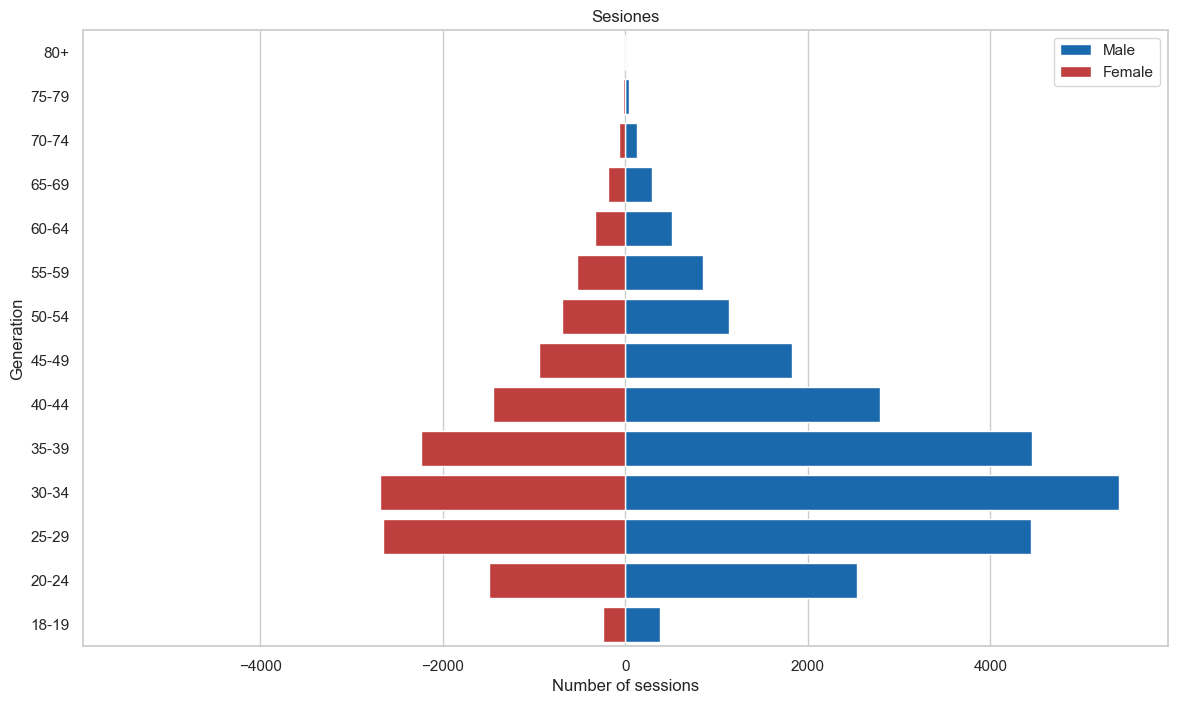

In [15]:
y_axis = "age_range_2"

df_preferences_users['datetime_x'] = pd.to_datetime(df_preferences_users['datetime_x'])

# Formatea la columna 'datetime_x' como año-mes-día
df_preferences_users['datetime_x'] = df_preferences_users['datetime_x'].dt.strftime('%Y-%m-%d')
df_preferences_users_sex= df_preferences_users[['uuid','sex','age_range_2','datetime_x']].drop_duplicates()
# Cuenta las votaciones según rango de edad y sexo
pop = df_preferences_users_sex.groupby([y_axis, "sex"]).agg({"uuid": "count"}).reset_index()

# Selecciona la información del sexo masculino
male = pop[pop["sex"].isin(["Male", "Masculino"])].copy()
# Selecciona la información del sexo femenino
female = pop[pop["sex"].isin(["Female", "Femenino"])].copy()

# Convierte el número de votos en un número negativo para poder graficarlo al lado izquierdo con respecto al cero.
female["uuid"] = female["uuid"] * -1

# Número levemente mayor al máximo de votos por usuario. Se define este valor para ocuparlo como xlim en las sgtes figuras.
m = pop['uuid'].abs().max() * 1.1

f, axes = plt.subplots(1, 1)
#Figura arriba a la derecha
ax = sns.barplot(y=y_axis, x="uuid", data=male, color="#006BC5",label='Male') 
ax = sns.barplot(y=y_axis, x="uuid", data=female, color="#D42929",label='Female')
ax.invert_yaxis()
ax.set_xlabel("Number of sessions")
ax.set_ylabel("Generation")
ax.set_title('Sesiones')
ax.set_xlim(-m, m)
ax.legend()
plt.show()


**La siguiente figura muestra la cantidad de hombres y mujeres de acuerdo a su edad, de los resultados definitivos del Censo 2017**

WARNING *** file size (2170752) not 512 + multiple of sector size (512)


C:\Users\cmurua\AppData\Local\Temp\ipykernel_21236\1700197535.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  female["MUJERES ÁREA URBANA"] = female['MUJERES ÁREA URBANA'] * -1


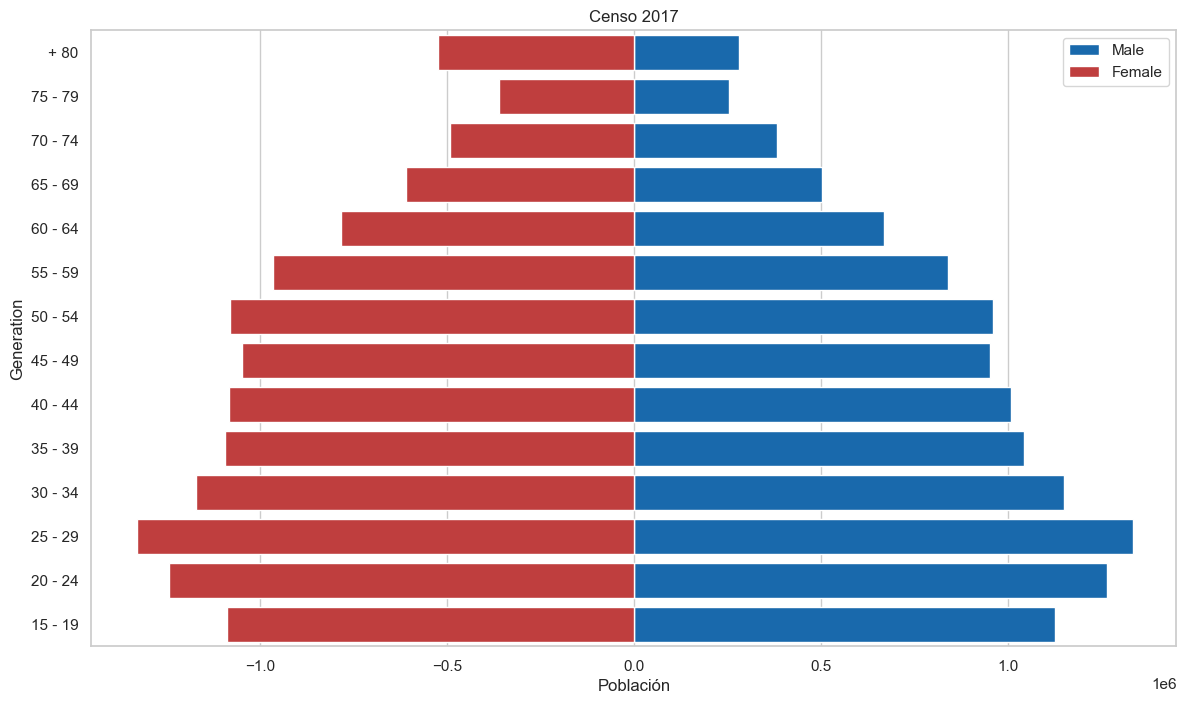

In [16]:

censo= pd.read_excel('data/1_2_POBLACION.xls',sheet_name='Región',header=2)
censo = censo[1:]
censo = censo[censo['GRUPOS DE EDAD'] != 'Total Región']
censo['GRUPOS DE EDAD'] = censo['GRUPOS DE EDAD'].str.replace('a', '-')

# Se filtran las edades que no son de interes
censo = censo[(censo['GRUPOS DE EDAD']!='0 - 4')&(censo['GRUPOS DE EDAD']!= '5 - 9')&(censo['GRUPOS DE EDAD']!= '10 - 14')]
filtro = censo[(censo['GRUPOS DE EDAD']=='80 - 84')|(censo['GRUPOS DE EDAD']=='85 - 89')|(censo['GRUPOS DE EDAD']=='90 - 94')|
              (censo['GRUPOS DE EDAD']=='95 - 99')|(censo['GRUPOS DE EDAD']=='100 o más')]
censo = censo[(censo['GRUPOS DE EDAD']!='80 - 84')&(censo['GRUPOS DE EDAD']!='85 - 89')&(censo['GRUPOS DE EDAD']!='90 - 94')&
              (censo['GRUPOS DE EDAD']!='95 - 99')&(censo['GRUPOS DE EDAD']!='100 o más')]
censo = censo[['GRUPOS DE EDAD','HOMBRES ÁREA URBANA ','MUJERES ÁREA URBANA']]

filtro= filtro[['HOMBRES ÁREA URBANA ','MUJERES ÁREA URBANA']].sum()
filtro['GRUPOS DE EDAD'] = '+ 80'
filtro = pd.DataFrame(filtro).T
censo = pd.concat([censo,filtro],axis=0)

grupos_de_edad_mapeo = {
    '15 - 19': 0,
    '20 - 24': 1,
    '25 - 29': 2,
    '30 - 34': 3,
    '35 - 39': 4,
    '40 - 44': 5,
    '45 - 49': 6,
    '50 - 54': 7,
    '55 - 59': 8,
    '60 - 64': 9,
    '65 - 69': 10,
    '70 - 74': 11,
    '75 - 79': 12,
    '+ 80':13,
}

# Aplicar el mapeo y ordenar el DataFrame
male = censo[['GRUPOS DE EDAD','HOMBRES ÁREA URBANA ']]
male= male.groupby('GRUPOS DE EDAD')['HOMBRES ÁREA URBANA '].sum().reset_index()
male['Orden'] = male['GRUPOS DE EDAD'].map(grupos_de_edad_mapeo)
male= male.sort_values(by='Orden').drop('Orden', axis=1)


female = censo[['GRUPOS DE EDAD','MUJERES ÁREA URBANA']]
female["MUJERES ÁREA URBANA"] = female['MUJERES ÁREA URBANA'] * -1
female = female.groupby('GRUPOS DE EDAD')['MUJERES ÁREA URBANA'].sum().reset_index()
female['Orden'] = female['GRUPOS DE EDAD'].map(grupos_de_edad_mapeo)
female= female.sort_values(by='Orden').drop('Orden', axis=1)


# Número levemente mayor al máximo de votos por usuario. Se define este valor para ocuparlo como xlim en las sgtes figuras.
m = 1000000*1.45

f, axes = plt.subplots(1, 1)
#Figura arriba a la derecha
ax = sns.barplot(y='GRUPOS DE EDAD', x='HOMBRES ÁREA URBANA ', data=male, color="#006BC5",label='Male') 
ax = sns.barplot(y='GRUPOS DE EDAD', x='MUJERES ÁREA URBANA', data=female, color="#D42929",label='Female')
ax.invert_yaxis()
ax.set_xlabel("Población")
ax.set_ylabel("Generation")
ax.set_title('Censo 2017')
ax.set_xlim(-m, m)
ax.legend()
plt.show()


**La siguiente figura presenta información sobre el género y la distribución por edades de los votantes que participaron en las elecciones convencionales constituyentes, gobernadores regionales, alcaldes y concejales del año 2021. Cabe mencionar que no se dispone de la base de datos de la elección más reciente, que tuvo lugar en 2023.**


C:\Users\cmurua\AppData\Local\Temp\ipykernel_21236\1844666177.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  male[col] = male[col].apply(lambda x: x * 1000 if str(x)[-1] != '0' else x)
C:\Users\cmurua\AppData\Local\Temp\ipykernel_21236\1844666177.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  female[col] = female[col].apply(lambda x: x * 1000 if str(x)[-1] != '0' else x)


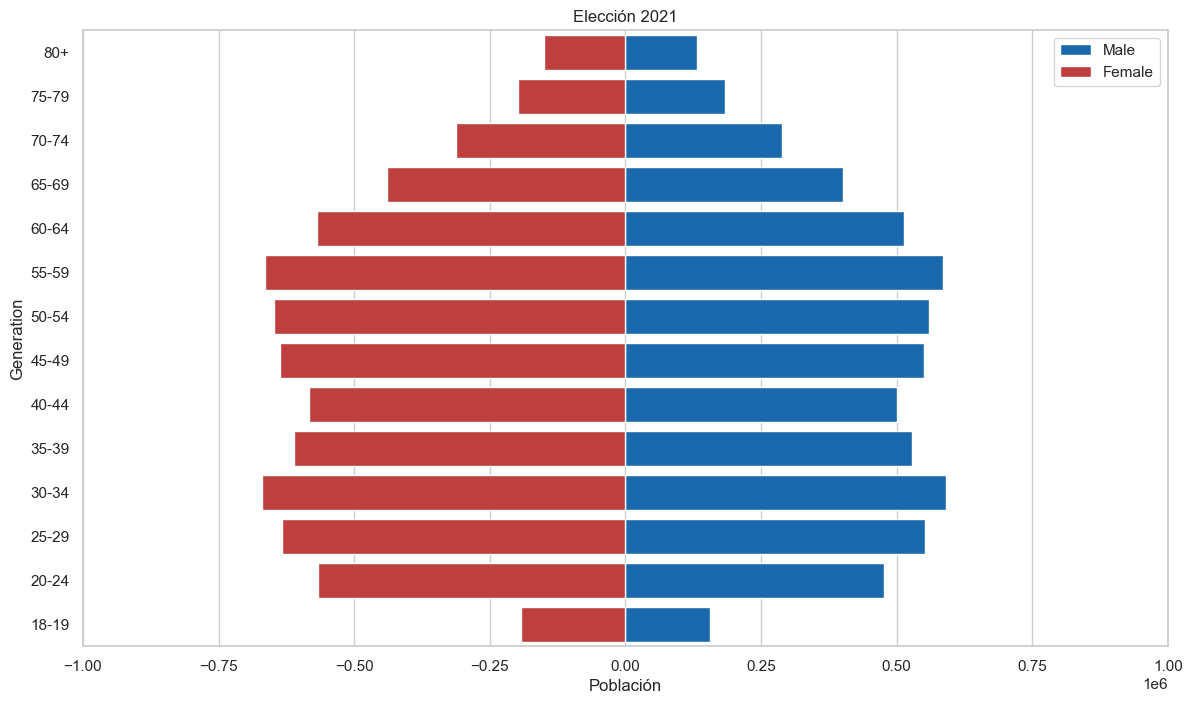

In [17]:

# Especifica la ruta al archivo PDF que deseas abrir
archivo_pdf = "data/votan_mayo2021_todos_rangoe_Chile_v2_cantidad_region.pdf"

# Utiliza tabula para extraer la tabla del PDF y guardarla en una lista de DataFrames
lista_dataframes = read_pdf(archivo_pdf, pages='all')

# Combina todos los DataFrames en uno solo (si hay varias páginas)
dataframe_final = pd.concat(lista_dataframes, ignore_index=True)
dataframe_final = dataframe_final.drop(columns=['Unnamed: 0','Región','Unnamed: 1','Total'])

# Ahora tienes tu tabla PDF como un DataFrame de pan
male = dataframe_final[dataframe_final['Sexo']=='V']
female = dataframe_final[dataframe_final['Sexo']=='M']

for col in male.columns[1:]:
    male[col] = male[col].apply(lambda x: x * 1000 if str(x)[-1] != '0' else x)
    female[col] = female[col].apply(lambda x: x * 1000 if str(x)[-1] != '0' else x)

male = pd.DataFrame(male.sum(axis=0).reset_index()[1:])
male.columns = ['GRUPO DE EDAD','COUNT']
female = pd.DataFrame(female.sum(axis=0).reset_index()[1:])
female.columns = ['GRUPO DE EDAD','COUNT']
female['COUNT'] = female['COUNT']*-1


# Número levemente mayor al máximo de votos por usuario. Se define este valor para ocuparlo como xlim en las sgtes figuras.
m = 1000000
f, axes = plt.subplots(1, 1)
#Figura arriba a la derecha
ax = sns.barplot(y='GRUPO DE EDAD', x='COUNT', data=male, color="#006BC5",label='Male') 
ax = sns.barplot(y='GRUPO DE EDAD', x='COUNT', data=female, color="#D42929",label='Female')
ax.invert_yaxis()
ax.set_xlabel("Población")
ax.set_ylabel("Generation")
ax.set_title('Elección 2021')
ax.legend()
ax.set_xlim(-m, m)
plt.show()

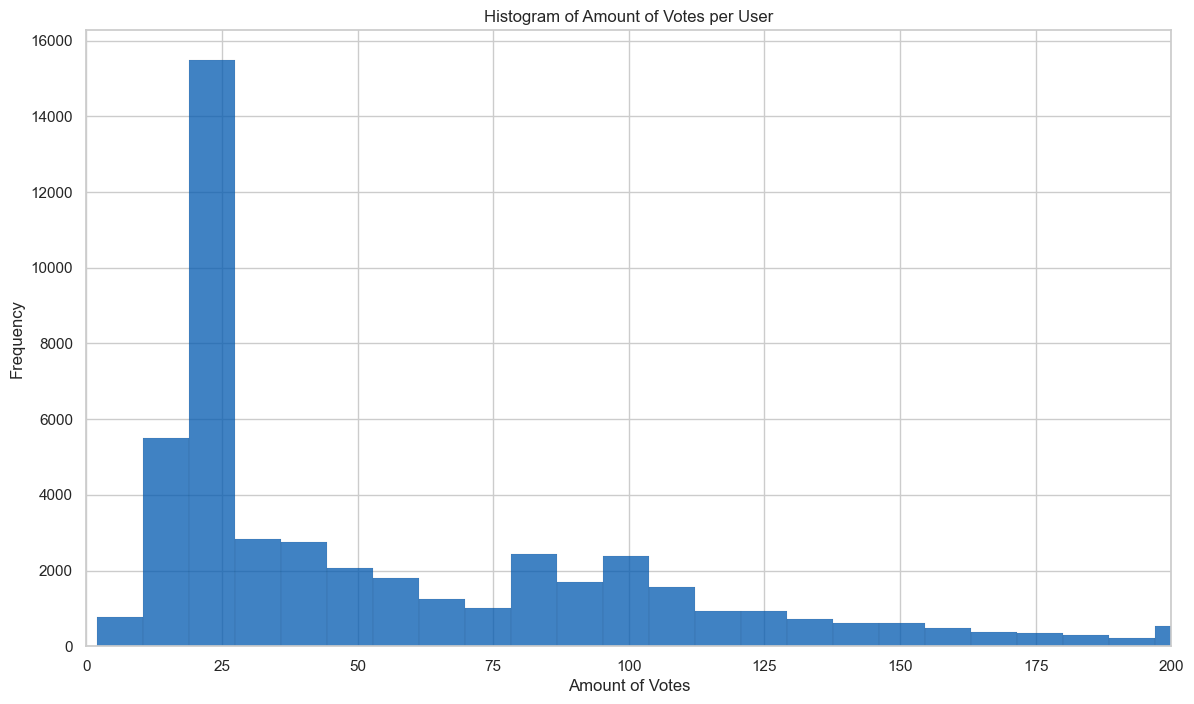

In [18]:

# Agrupa el DataFrame 'df_nuevo' por la columna 'uuid' y calcula la cantidad de elementos en cada grupo
cantidad = df.groupby('uuid').agg(cantidad=('id', 'count'))

sns.set(style="whitegrid", rc={"axes.grid": False})

# Genera un histograma de los valores de 'cantidad' utilizando 200 bins y la paleta de colores personalizada
sns.histplot(cantidad,x ='cantidad' , bins=2000, kde=False,color="#0058af", edgecolor='black')

# Cambia el título a 'Histogram of Amount of Votes per User'
plt.title('Histogram of Amount of Votes per User')

# Cambia el color del histograma a verde
plt.xlabel('Amount of Votes')  # Cambiado el color de la etiqueta x a verde
plt.ylabel('Frequency')  # Cambiado el color de la etiqueta y a verde
# Muestra el gráfico
plt.xlim(0,200)
plt.grid()
plt.show()

**Cantidad de votaciones por semana.**

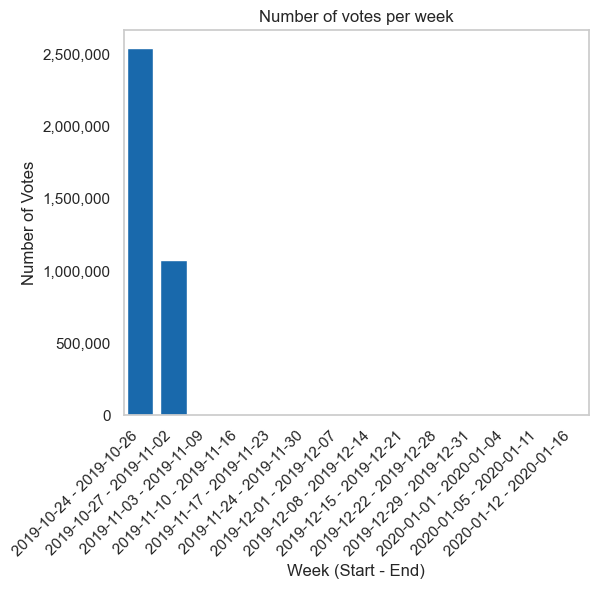

In [32]:
from matplotlib.ticker import FuncFormatter

# Agrupa por semana y cuenta el número de votaciones por semana
votaciones_por_semana = df.groupby(df['datetime'].dt.strftime('%Y-%U'))['uuid'].count().reset_index(name='Cantidad de Votaciones')


# Agrupa por semana y cuenta el número de votaciones por semana
votaciones_por_semana_completo = completo.groupby(completo['datetime'].dt.strftime('%Y-%U'))['uuid'].count().reset_index(name='Cantidad de Votaciones_1')
votaciones_por_semana_merge = votaciones_por_semana_completo.merge(votaciones_por_semana,on='datetime',how='outer')
votaciones_por_semana_merge = votaciones_por_semana_merge.fillna(0)

# Obtiene las fechas de inicio y fin de semana
semanas = completo.groupby(completo['datetime'].dt.strftime('%Y-%U'))['datetime'].agg(['min', 'max']).reset_index()

# Crea una figura y un eje para la gráfica de barras
fig, ax = plt.subplots(figsize=(6, 5))
sns.set(style="whitegrid", rc={"axes.grid": False})
# Utiliza Seaborn para graficar la cantidad de votaciones por semana
sns.barplot(x='datetime', y='Cantidad de Votaciones', data=votaciones_por_semana_merge, color="#006BC5", ax=ax)

# Configura las etiquetas de los ejes
ax.set_xlabel('Week (Start - End)')
ax.set_ylabel('Number of Votes')

# Formatea el eje y para agregar separadores de miles
ax.get_yaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

ax.set_title('Number of votes per week')

# Establece las etiquetas del eje x con las fechas de inicio y fin de semana y alinea horizontalmente al centro
labels = [f"{inicio} - {fin}" for inicio, fin in zip(semanas['min'].dt.strftime('%Y-%m-%d'), semanas['max'].dt.strftime('%Y-%m-%d'))]
ax.set_xticklabels(labels, rotation=45, ha='right')  # Rotación de 45 grados y alineación a la derecha

plt.show()

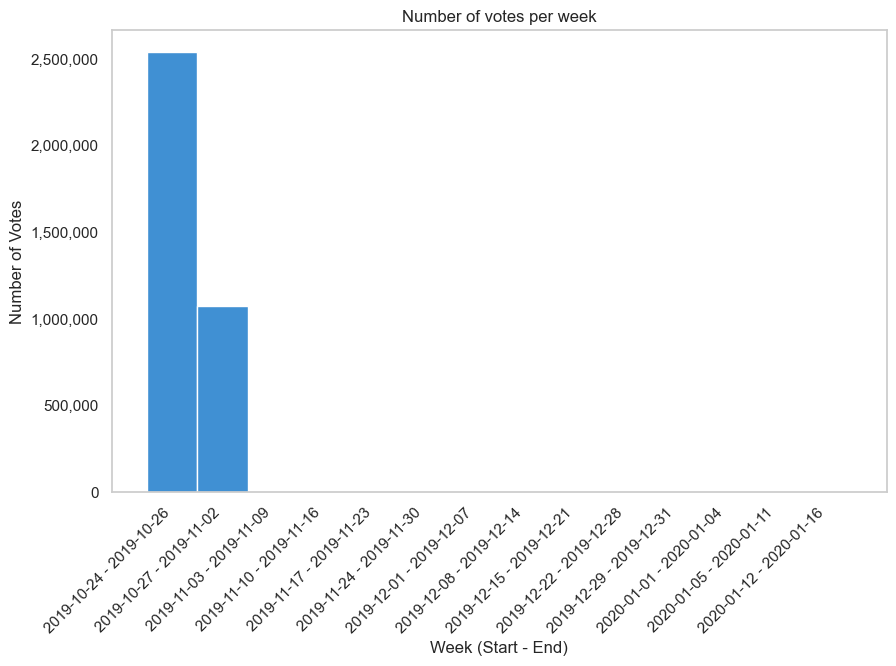

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Supongamos que 'df' y 'completo' son tus DataFrames existentes
# Aquí está el código modificado para crear un histograma

# Agrupa por semana y cuenta el número de votaciones por semana
votaciones_por_semana = df.groupby(df['datetime'].dt.strftime('%Y-%U'))['uuid'].count().reset_index(name='Cantidad de Votaciones')

# Agrupa por semana y cuenta el número de votaciones por semana
votaciones_por_semana_completo = completo.groupby(completo['datetime'].dt.strftime('%Y-%U'))['uuid'].count().reset_index(name='Cantidad de Votaciones_1')
votaciones_por_semana_merge = votaciones_por_semana_completo.merge(votaciones_por_semana, on='datetime', how='outer')
votaciones_por_semana_merge = votaciones_por_semana_merge.fillna(0)

# Obtiene las fechas de inicio y fin de semana
semanas = completo.groupby(completo['datetime'].dt.strftime('%Y-%U'))['datetime'].agg(['min', 'max']).reset_index()

# Crea una figura y un eje para el histograma
fig, ax = plt.subplots(figsize=(10, 6))
sns.set(style="whitegrid", rc={"axes.grid": False})

# Utiliza Seaborn para graficar el histograma de la cantidad de votaciones por semana
sns.histplot(data=votaciones_por_semana_merge, x='datetime', weights='Cantidad de Votaciones', bins=len(votaciones_por_semana_merge), color="#006BC5", ax=ax)

# Configura las etiquetas de los ejes
ax.set_xlabel('Week (Start - End)')
ax.set_ylabel('Number of Votes')

# Formatea el eje y para agregar separadores de miles
ax.get_yaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

ax.set_title('Number of votes per week')

# Establece las etiquetas del eje x con las fechas de inicio y fin de semana y alinea horizontalmente al centro
labels = [f"{inicio} - {fin}" for inicio, fin in zip(semanas['min'].dt.strftime('%Y-%m-%d'), semanas['max'].dt.strftime('%Y-%m-%d'))]
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')  # Rotación de 45 grados y alineación a la derecha

plt.show()
